# Construcción de la Tabla Maestra v2

Este notebook integra únicamente las dos fuentes con cobertura completa
y granularidad equivalente:

- **BD_Residencia_modelo**: flujo de turistas extranjeros por país de residencia.
  Es la **variable objetivo** del modelo (lo que queremos predecir).
- **BD_Nacionalidad_modelo**: flujo de turistas por pasaporte/nacionalidad.
  Feature adicional que captura la diferencia entre dónde vive el turista
  y cuál es su nacionalidad, información clave para segmentar campañas de marketing.

**¿Por qué se excluye BD_AFAC?**
- Solo tiene datos desde 2016. Residencia y Nacionalidad cubren desde 2012,
  por lo que incluir AFAC obligaría a poner ceros falsos en 2012–2015.
- Está agregada a nivel mes global, no por aeropuerto: Cancún y Acapulco
  recibirían el mismo valor, sin poder discriminar entre rutas.
- Su importancia en el modelo anterior fue prácticamente cero,
  confirmando que no aporta poder predictivo.

**Producto final:** `tabla_maestra2.csv` con Residencia + Nacionalidad.

## 1. Carga de los datasets limpios

Se cargan las dos tablas desde el repositorio GitHub.
Se imprime dimensión, columnas y tipos de dato para confirmar
la integridad de los archivos antes de la integración.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (13, 5)

BASE = "https://github.com/Montiel-Oscar/ciencia_de_datos_2026_2/raw/fe2b43566671a36f2e24f028a140bfd69d20ecd3/proyecto_borrador/datasets/"

print("Cargando tablas...")
df_res = pd.read_csv(BASE + "BD_Residencia_modelo_v3.csv")
df_nac = pd.read_csv(BASE + "BD_Nacionalidad_modelo_v2.csv")

print(f"Residencia:   {len(df_res):,} filas — columnas: {df_res.columns.tolist()}")
print(f"Nacionalidad: {len(df_nac):,} filas — columnas: {df_nac.columns.tolist()}")
print(f"\nTipos de dato — Residencia:")
print(df_res.dtypes)
print(f"\nPrimeras 3 filas:")
print(df_res.head(3))

Cargando tablas...
Residencia:   382,747 filas — columnas: ['Año', 'MesNum', 'Aeropuerto', 'Pais', 'Región', 'Sexo', 'Valor']
Nacionalidad: 445,547 filas — columnas: ['Año', 'MesNum', 'Aeropuerto', 'Pais', 'Región', 'Sexo', 'Valor']

Tipos de dato — Residencia:
Año            int64
MesNum         int64
Aeropuerto    object
Pais          object
Región        object
Sexo          object
Valor          int64
dtype: object

Primeras 3 filas:
    Año  MesNum      Aeropuerto       Pais   Región    Sexo  Valor
0  2012       1  acapulco, gro.   alemania   europa  hombre      1
1  2012       1  acapulco, gro.   alemania   europa   mujer      1
2  2012       1  acapulco, gro.  australia  oceania  hombre      6


## 2. Verificación de compatibilidad entre tablas

Antes del JOIN se confirma que las columnas de texto tienen exactamente
los mismos valores en ambas fuentes. Una discrepancia mínima
(por ejemplo, `'cancun, q. roo'` vs `'cancún, q. roo'`) produciría
un JOIN silenciosamente incorrecto: los registros no se unirían
pero el código no generaría ningún error, inflando los nulos.

También se verifica que los rangos de años y los valores de Sexo coincidan.

In [ ]:
print("Aeropuerto — Residencia (muestra):")
print(df_res['Aeropuerto'].unique()[:5])
print("\nAeropuerto — Nacionalidad (muestra):")
print(df_nac['Aeropuerto'].unique()[:5])

print(f"\nAños Residencia:   {sorted(df_res['Año'].unique())}")
print(f"Años Nacionalidad: {sorted(df_nac['Año'].unique())}")

print(f"\nSexo Residencia:   {df_res['Sexo'].unique()}")
print(f"Sexo Nacionalidad: {df_nac['Sexo'].unique()}")

# Verificar aeropuertos en ambas tablas
aero_res = set(df_res['Aeropuerto'].unique())
aero_nac = set(df_nac['Aeropuerto'].unique())
solo_res = aero_res - aero_nac
solo_nac = aero_nac - aero_res
print(f"\nAeropuertos solo en Residencia:   {solo_res if solo_res else 'ninguno'}")
print(f"Aeropuertos solo en Nacionalidad: {solo_nac if solo_nac else 'ninguno '}")

# Verificar países
paises_res = set(df_res['Pais'].unique())
paises_nac = set(df_nac['Pais'].unique())
print(f"\nPaíses únicos — Residencia:   {len(paises_res)}")
print(f"Países únicos — Nacionalidad: {len(paises_nac)}")
diff = paises_nac - paises_res
print(f"Países en Nacionalidad pero no en Residencia: {diff if diff else 'ninguno '}")

Aeropuerto — Residencia (muestra):
['acapulco, gro.' 'aguascalientes, ags.' 'cabo san lucas, b.c.s.'
 'campeche, camp.' 'cancun, q. roo']

Aeropuerto — Nacionalidad (muestra):
['acapulco, gro.' 'aguascalientes, ags.' 'cabo san lucas, b.c.s.'
 'campeche, camp.' 'cancun, q. roo']

Años Residencia:   [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Años Nacionalidad: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Sexo Residencia:   ['hombre' 'mujer']
Sexo Nacionalidad: ['hombre' 'mujer']

Aeropuertos solo en Residencia:   ninguno
Aeropuertos solo en Nacionalidad: ninguno 

Países únicos — Residencia:   243
Países únicos — Nacionalidad: 236
Países en Nacionalidad pero no en Residencia: {'azores, islas', 

## 3. JOIN entre Residencia y Nacionalidad

Se realiza un LEFT JOIN tomando **Residencia como tabla base**,
ya que su variable `Valor` es la variable objetivo del modelo.
Nacionalidad aporta su `Valor` como feature adicional.

**Clave del JOIN:** `Año + MesNum + Aeropuerto + Pais + Sexo`

El LEFT JOIN conserva el 100% de los registros de Residencia.
Los registros sin contraparte en Nacionalidad generarán nulos
en `Valor_Nacionalidad`, que se tratan en la sección siguiente.

Se verifica antes del JOIN que no haya duplicados en ninguna tabla,
ya que los duplicados multiplicarían filas y distorsionarían los datos.

In [ ]:
CLAVE = ['Año', 'MesNum', 'Aeropuerto', 'Pais', 'Sexo']

df_res_j = df_res.rename(columns={'Valor': 'Valor_Residencia'})
df_nac_j = df_nac[CLAVE + ['Valor']].rename(columns={'Valor': 'Valor_Nacionalidad'})

dupes_res = df_res_j.duplicated(subset=CLAVE).sum()
dupes_nac = df_nac_j.duplicated(subset=CLAVE).sum()
print(f"Duplicados en Residencia:   {dupes_res}")
print(f"Duplicados en Nacionalidad: {dupes_nac}")

df_master = df_res_j.merge(df_nac_j, on=CLAVE, how='left')

print(f"\nResidencia original: {len(df_res):,} filas")
print(f"Tabla tras JOIN:     {len(df_master):,} filas")
print(f"Nulos en Valor_Nac:  {df_master['Valor_Nacionalidad'].isnull().sum():,} "
      f"({df_master['Valor_Nacionalidad'].isnull().mean()*100:.1f}%)")

assert len(df_master) == len(df_res), \
    f"ERROR: el merge generó filas extra ({len(df_master)} vs {len(df_res)})"
print("\n JOIN correcto — filas conservadas sin multiplicación")
print(df_master.head())

Duplicados en Residencia:   0
Duplicados en Nacionalidad: 0

Residencia original: 382,747 filas
Tabla tras JOIN:     382,747 filas
Nulos en Valor_Nac:  48,460 (12.7%)

 JOIN correcto — filas conservadas sin multiplicación
    Año  MesNum      Aeropuerto       Pais            Región    Sexo  \
0  2012       1  acapulco, gro.   alemania            europa  hombre   
1  2012       1  acapulco, gro.   alemania            europa   mujer   
2  2012       1  acapulco, gro.  australia           oceania  hombre   
3  2012       1  acapulco, gro.  australia           oceania   mujer   
4  2012       1  acapulco, gro.   barbados  islas del caribe  hombre   

   Valor_Residencia  Valor_Nacionalidad  
0                 1                 1.0  
1                 1                 1.0  
2                 6                 6.0  
3                 1                 1.0  
4                 1                 1.0  


## 4. Tratamiento de nulos en Valor_Nacionalidad

Los nulos en `Valor_Nacionalidad` corresponden a combinaciones que
el gobierno registró en Residencia pero no publicó en Nacionalidad.

**Estrategia de imputación:** rellenar con `Valor_Residencia`.
Lógica: si no sabemos cuántos turistas de pasaporte X llegaron,
el mejor proxy disponible es cuántos residentes de ese país llegaron.

Se crea el flag `nac_imputada` **antes del fillna** para registrar
qué filas fueron imputadas vs cuáles tenían dato real.

In [ ]:
df_master['nac_imputada'] = df_master['Valor_Nacionalidad'].isna().astype(int)

df_master['Valor_Nacionalidad'] = df_master['Valor_Nacionalidad'].fillna(
    df_master['Valor_Residencia']
)

print(f"Registros imputados (nac_imputada=1): {df_master['nac_imputada'].sum():,} "
      f"({df_master['nac_imputada'].mean()*100:.1f}%)")
print(f"Nulos en Valor_Nacionalidad tras imputar: {df_master['Valor_Nacionalidad'].isnull().sum()}")
print(f"Nulos totales en la tabla: {df_master.isnull().sum().sum()}")
print(f"\nSin nulos")

Registros imputados (nac_imputada=1): 48,460 (12.7%)
Nulos en Valor_Nacionalidad tras imputar: 0
Nulos totales en la tabla: 0

Sin nulos


## 5. Exclusión de años COVID y 2026

Para el dataset de modelado se excluyen:
- **2020 y 2021**: pandemia COVID-19. Los patrones son anómalos
  y contaminarían el aprendizaje de patrones normales.
- **2026**: solo tiene enero disponible. Un año incompleto distorsiona
  los promedios anuales y los lag features.

Se conserva el dataset completo para análisis descriptivo
y para las visualizaciones del pitch.

Dataset completo: 382,747 filas | 2012–2025
Dataset modelo:   382,747 filas
Años en modelo:   [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


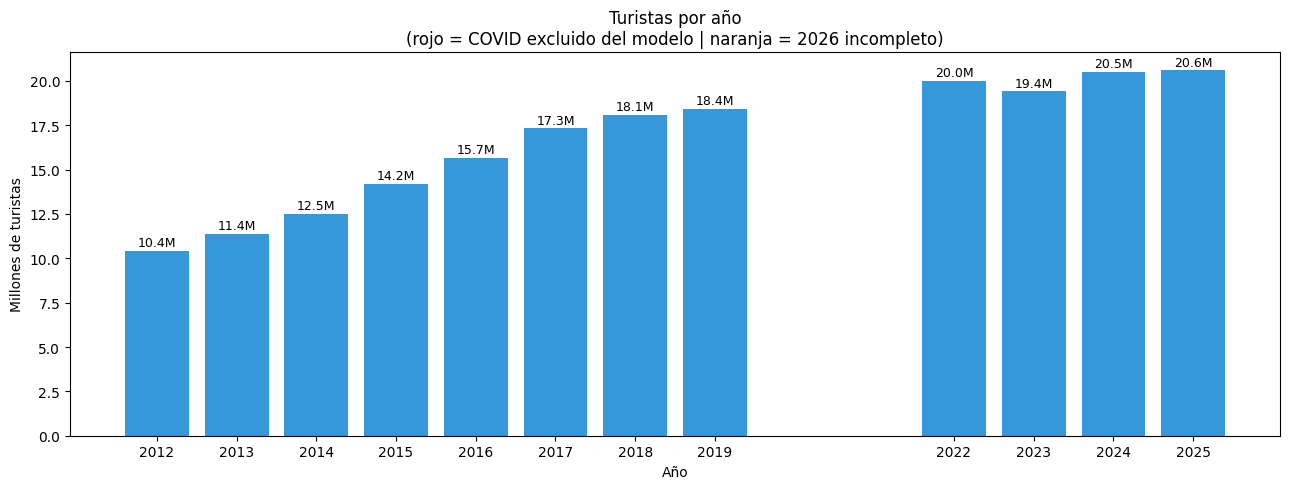

In [ ]:
df_completo = df_master.copy()
df_modelo   = df_master[~df_master['Año'].isin([2020, 2021, 2026])].copy()

print(f"Dataset completo: {len(df_completo):,} filas | {df_completo['Año'].min()}–{df_completo['Año'].max()}")
print(f"Dataset modelo:   {len(df_modelo):,} filas")
print(f"Años en modelo:   {sorted(df_modelo['Año'].unique())}")

turistas_año = df_completo.groupby('Año')['Valor_Residencia'].sum().reset_index()
colores = ['#e74c3c' if a in [2020, 2021] else
           '#f39c12' if a == 2026 else '#3498db'
           for a in turistas_año['Año']]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(turistas_año['Año'], turistas_año['Valor_Residencia']/1e6, color=colores)
for bar, val in zip(bars, turistas_año['Valor_Residencia']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val/1e6:.1f}M', ha='center', va='bottom', fontsize=9)
ax.set_title('Turistas por año\n(rojo = COVID excluido del modelo | naranja = 2026 incompleto)')
ax.set_ylabel('Millones de turistas')
ax.set_xlabel('Año')
ax.set_xticks(turistas_año['Año'])
plt.tight_layout()
plt.show()

## 6. Validación de sentido de negocio

Se realizan comprobaciones sobre los datos finales para detectar
errores silenciosos. Los resultados deben ser coherentes con
la realidad del turismo en México:
- Cancún debe ser el aeropuerto con mayor volumen.
- EE.UU. debe ser el país de residencia #1.
- Marzo y diciembre deben tener más turistas que septiembre.

In [ ]:
print("=" * 55)
print("VALIDACIÓN DE SENTIDO DE NEGOCIO")
print("=" * 55)

print(f"\nAños cubiertos: {df_modelo['Año'].min()}–{df_modelo['Año'].max()}")
print(f"Aeropuertos:    {df_modelo['Aeropuerto'].nunique()}")
print(f"Países:         {df_modelo['Pais'].nunique()}")
print(f"Regiones:       {df_modelo['Región'].nunique()}")

print("\nTop 5 aeropuertos por volumen total:")
top_aero = (df_modelo.groupby('Aeropuerto')['Valor_Residencia']
            .sum().sort_values(ascending=False).head(5))
for aero, val in top_aero.items():
    print(f"  {aero:<35} {val:>12,.0f}")

print("\nTop 5 países de residencia por volumen total:")
top_pais = (df_modelo.groupby('Pais')['Valor_Residencia']
            .sum().sort_values(ascending=False).head(5))
for pais, val in top_pais.items():
    print(f"  {pais:<30} {val:>12,.0f}")


estacional = df_modelo.groupby('MesNum')['Valor_Residencia'].sum()
check1 = 'cancun, q. roo' == top_aero.index[0]
check2 = 'estados unidos' == top_pais.index[0]
check3 = estacional[3] > estacional[9]
check4 = estacional[12] > estacional[9]

print(f"\nCancún es aeropuerto #1:          {check1}")
print(f"EE.UU. es país #1:                {check2}")
print(f" Marzo > Septiembre (estacionalidad): {check3}")
print(f"Diciembre > Septiembre:            {check4}")

if all([check1, check2, check3, check4]):
    print("\nTODAS LAS VALIDACIONES PASARON — datos coherentes")
else:
    print("\nREVISAR — alguna validación falló")

VALIDACIÓN DE SENTIDO DE NEGOCIO

Años cubiertos: 2012–2025
Aeropuertos:    66
Países:         243
Regiones:       8

Top 5 aeropuertos por volumen total:
  cancun, q. roo                        88,581,551
  ciudad de mexico (aicm)               41,680,628
  los cabos, b.c.s.                     20,094,250
  puerto vallarta, jal.                 16,610,677
  guadalajara, jal.                     11,645,285

Top 5 países de residencia por volumen total:
  estados unidos                  123,620,908
  canada                           23,912,885
  reino unido                       5,672,372
  colombia                          5,233,093
  argentina                         3,842,391

Cancún es aeropuerto #1:          True
EE.UU. es país #1:                True
 Marzo > Septiembre (estacionalidad): True
Diciembre > Septiembre:            True

TODAS LAS VALIDACIONES PASARON — datos coherentes


## 7. Reporte final de la tabla maestra

Se muestra el estado completo de la tabla antes de exportarla:
dimensiones, tipos de dato, nulos y muestra de 10 filas.

In [ ]:
print("=" * 60)
print("TABLA MAESTRA v2 — REPORTE FINAL")
print("=" * 60)
print(f"Filas:          {len(df_modelo):,}")
print(f"Columnas:       {df_modelo.shape[1]}")
print(f"Años:           {df_modelo['Año'].min()}–{df_modelo['Año'].max()}")
print(f"Aeropuertos:    {df_modelo['Aeropuerto'].nunique()}")
print(f"Países:         {df_modelo['Pais'].nunique()}")
print(f"Nulos totales:  {df_modelo.isnull().sum().sum()}")

print(f"\nColumnas y tipos:")
for col in df_modelo.columns:
    nulos = df_modelo[col].isnull().sum()
    print(f"  {col:<25} {str(df_modelo[col].dtype):<12} nulos: {nulos}")

print(f"\nTarget (Valor_Residencia):")
print(f"  Min:    {df_modelo['Valor_Residencia'].min():,}")
print(f"  Max:    {df_modelo['Valor_Residencia'].max():,}")
print(f"  Media:  {df_modelo['Valor_Residencia'].mean():,.1f}")
print(f"  Mediana:{df_modelo['Valor_Residencia'].median():,.0f}")

print("\nMuestra de 10 filas (primeras 5 + últimas 5):")
print(pd.concat([df_modelo.head(5), df_modelo.tail(5)]).to_string())

TABLA MAESTRA v2 — REPORTE FINAL
Filas:          382,747
Columnas:       9
Años:           2012–2025
Aeropuertos:    66
Países:         243
Nulos totales:  0

Columnas y tipos:
  Año                       int64        nulos: 0
  MesNum                    int64        nulos: 0
  Aeropuerto                object       nulos: 0
  Pais                      object       nulos: 0
  Región                    object       nulos: 0
  Sexo                      object       nulos: 0
  Valor_Residencia          int64        nulos: 0
  Valor_Nacionalidad        float64      nulos: 0
  nac_imputada              int64        nulos: 0

Target (Valor_Residencia):
  Min:    1
  Max:    332,671
  Media:  518.6
  Mediana:4

Muestra de 10 filas (primeras 5 + últimas 5):
         Año  MesNum         Aeropuerto         Pais            Región    Sexo  Valor_Residencia  Valor_Nacionalidad  nac_imputada
0       2012       1     acapulco, gro.     alemania            europa  hombre                 1             

## 8. Exportación

Se exporta `tabla_maestra2.csv` con todos los datos listos.
El feature engineering (lags, encoding, variables cíclicas)
se realizará en el siguiente notebook para mantener separadas
las responsabilidades de cada etapa del pipeline.

In [ ]:
df_modelo.to_csv('tabla_maestra2.csv', index=False)

from google.colab import files
files.download('tabla_maestra2.csv')

print("=" * 55)
print("TABLA MAESTRA v2 — DESCARGADA EXITOSAMENTE")
print("=" * 55)
print(f"Archivo:  tabla_maestra2.csv")
print(f"Filas:    {len(df_modelo):,}")
print(f"Columnas: {df_modelo.shape[1]}")
print(f"Nulos:    {df_modelo.isnull().sum().sum()}")
print(f"\nColumnas incluidas:")
for c in df_modelo.columns:
    print(f"  - {c}")
print("\nSiguiente paso: subir a GitHub y abrir el notebook de feature engineering.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

TABLA MAESTRA v2 — DESCARGADA EXITOSAMENTE
Archivo:  tabla_maestra2.csv
Filas:    382,747
Columnas: 9
Nulos:    0

Columnas incluidas:
  - Año
  - MesNum
  - Aeropuerto
  - Pais
  - Región
  - Sexo
  - Valor_Residencia
  - Valor_Nacionalidad
  - nac_imputada

Siguiente paso: subir a GitHub y abrir el notebook de feature engineering.
